In [1]:
# ==============================================================================
# PIPELINE 6C: Research Question 3 - Predicting Final Award Prices
# Objective: Estimate lot prices and evaluate the econometric impact of competition.
# ==============================================================================
import pandas as pd
import numpy as np
from src.training.preparation import perform_group_split
from src.training.optimization import tune_supervised_model
from src.training.evaluation import evaluate_regression, plot_feature_importance

pd.set_option('display.max_columns', None)

In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Load Data & Methodological Filtering
# ------------------------------------------------------------------------------
print("Loading prepared dataset...")
dataset_full = pd.read_parquet("data/prepared/ted_prepared.parquet")

# Methodological requirement: Estimated values (budgets) are only published on 
# notice level. To correctly map budgets to final award prices, we strictly filter 
# for single-lot procedures.
# Note: LOTS_NUMBER was log1p-transformed. np.log1p(1) = 0.693147
single_lot_mask = np.isclose(dataset_full['LOTS_NUMBER'], np.log1p(1))
dataset_single_lots = dataset_full[single_lot_mask].copy()

print(f"Filtered for Single-Lot procedures: {len(dataset_single_lots):,} rows available for price prediction.")

Loading prepared dataset...
Filtered for Single-Lot procedures: 443,707 rows available for price prediction.


In [3]:
# ------------------------------------------------------------------------------
# STEP 2: Partitioning for Model A (Pure Planning Phase)
# ------------------------------------------------------------------------------
# We predict the price based ONLY on what the authority knows BEFORE publishing.
# Therefore, we strictly exclude the actual bidder count and notice-level targets.
exclusion_list_planning = ['TARGET_AWARD_VALUE_EUR', 'NUMBER_OF_TENDERS']

features_train_plan, features_test_plan, target_train_plan, target_test_plan, groups_train_plan = perform_group_split(
    df=dataset_single_lots, 
    target_col='LOT_AWARD_VALUE_EUR', 
    group_col='ID_NOTICE', 
    drop_cols=exclusion_list_planning
)

Executing Group-based Split (Target: 'LOT_AWARD_VALUE_EUR', Grouping by: 'ID_NOTICE')...
 -> Split successful. Train: 354,607 rows | Test: 89,100 rows.


In [4]:
# ------------------------------------------------------------------------------
# STEP 3: Train & Tune Planning Model
# ------------------------------------------------------------------------------
# We train the state-of-the-art XGBoost Regressor to estimate the final price.
best_price_model = tune_supervised_model(
    X_train=features_train_plan, 
    y_train=target_train_plan, 
    groups_train=groups_train_plan, 
    model_name='xgboost', 
    task='reg', 
    n_iter=5
)

\nInitiating Hyperparameter Tuning for 'XGBOOST' (REG)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
 -> Best parameters identified: {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.01}


\nEvaluating Regression Model...
 -> R² Score (Log-Scale): 0.4205
 -> RMSE (Original Scale): 6,652,594.28
 -> MAE  (Original Scale): 1,210,424.43


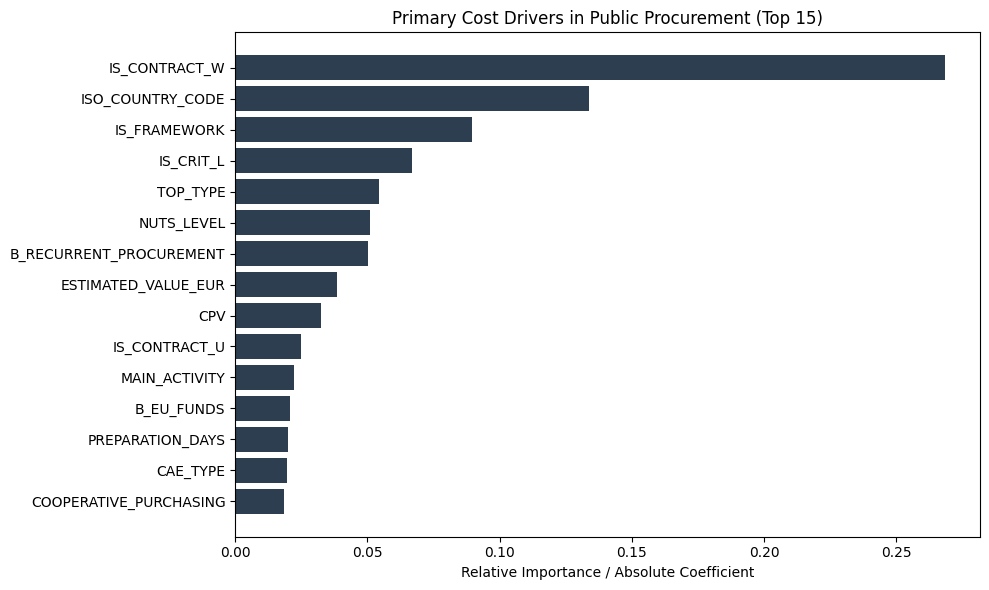

In [5]:
# ------------------------------------------------------------------------------
# STEP 4: Economic Evaluation
# ------------------------------------------------------------------------------
# The evaluate function automatically reverses the logarithmic transformation
# to output real-world Euro values.
predictions_euro = evaluate_regression(best_price_model, features_test_plan, target_test_plan)

plot_feature_importance(
    model=best_price_model, 
    feature_names=features_train_plan.columns, 
    title="Primary Cost Drivers in Public Procurement"
)